# Give Me Some Credit - Estudo

Meu objetivo é comparar métodos de regressão logística com diferentes formas de selecionar variáveis. 

Primeiro, faço uma breve análise do conjunto de dados com o tratamento de dados faltantes e um processo de engenharia de features nas variáveis que guardam o números atrasos de pagamento em um determinado prazo fixo. Como essas variáveis de atraso estão altamente correlacionadas, isso pode ser um problema para o modelo. Para evitar isso, agrupamos essas informações em uma única variável chamada `late_score` que faz uma soma ponderada dos atrasos em cada período. Além disso, nessa análise exploratória verificamos que o conjunto de dados disponível para treino é desbalanceado. Apenas cerca de $7\%$ dos dados correspondem a pessoas classificadas como más pagadoras. Se não modelado corretamente, isso pode levar a ajuste que classifica a maioria dos dados como bons pagadores ($y=0$). Para isso vamos procurar nos orientar usando a curva ROC para escolher um limiar que tenha um balanceamento entre **sensibilidade** e **especificidade**.

Feito essa primeira análise exploratória, vamos aos métodos de seleção de variáveis. A primeira forma de selecionar será baseada nos gráficos de boxplot comparando as distribuiçoes de cada variáveis explicativa pelas preditoras. Uma variável que indica uma forte depedência é a variável `late_score`. A variável `credit_utilization` também evidencia uma dependência, mas ao rodar o modelo de regressão logística do pacote `statsmodels` vemos que a partir do teste de hipóteses que a função `sm.GLM` apresenta, temos evidências para não rejeitar a hipótese de que essa variável possui significância estatística para o modelo. Por isso, vamos analisar o desempenho da variável `late_score` sozinha. As outras formas de seleção de variáveis são o AIC, o BIC e a regularização L1 Lasso.

Na avaliação de desempenho dos modelos de regressão logística usando a função logito como função de ligação, podemos observar que quando consideramos um limiar padrão de $0.5$, a sensibilidade dos modelos fica próxima de $0$, o que é muito ruim para avaliar risco de crédito, afinal, não queremos um modelo que tenha uma baixa taxa de acerto nos maus pagadores pois isso implica em conceder crédito a pessoas que não conseguirão pagar. Isso acontece porque os dados estão desbalanceados. Para contornar isso, fiz uma rotina para impõe um limite inferior para a sensibilidade e a partir disso busca por limiares que melhorem a **acurácia** do teste.

Os modelos com limiares otimizados confirmam a suposição de que os melhores limiares estão mais próximos do zero e o resultado foi satisfatório. Surpreendentemente, o modelo que leva em consideração apenas a variável `late_score` apresentou um ótimo resultado.

Para futuras análises, quero fazer análises de resíduos para veficar se o modelo precisa de algum ajuste e gráficos QQ plot para verificar se as suposições sobre o modelo estão corretas. Além disso gostaria de comparar a regressão logística logito com outros modelos.


## 1. Leitura dos dados


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

treino_0 = pd.read_csv('GiveMeSomeCredit/cs-training.csv')
teste_0 = pd.read_csv('GiveMeSomeCredit/cs-test.csv')

cols = {
    'Unnamed: 0': 'id',
    'SeriousDlqin2yrs': 'default_2y',
    'RevolvingUtilizationOfUnsecuredLines': 'credit_utilization',
    'age': 'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'late_30_59_days',
    'DebtRatio': 'debt_ratio',
    'MonthlyIncome': 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans': 'num_credit_lines',
    'NumberOfTimes90DaysLate': 'late_90_days',
    'NumberRealEstateLoansOrLines': 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'late_60_89_days',
    'NumberOfDependents': 'dependents'
}

treino = treino_0.rename(columns=cols).copy()
teste = teste_0.rename(columns=cols).copy()

treino.drop(columns = 'id', inplace = True)
teste.drop(columns = 'id', inplace = True)

treino.head()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Conhecendo os dados

Verificar tamanho dos dados, desbalanceamento da target e faltantes.

In [65]:
treino.describe()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [66]:
teste.describe()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


Podemos observar dados faltantes em ambos conjuntos de dados. Alem disso, temos linhas com 'age' igual a zero.

In [67]:
def resumo_faltantes(df):
    tabela = pd.DataFrame({
        'faltantes': df.isna().sum(),
        'faltantes (%)': df.isna().mean().mul(100)
    })
    return tabela[tabela['faltantes'] > 0].sort_values('faltantes', ascending=False)

print('Shape treino:', treino.shape)
print('Shape teste:', teste.shape)
taxa_default = treino['default_2y'].mean()
print(f"\nTaxa de default nos dados de treino: {taxa_default:.2%}")

display(resumo_faltantes(treino))
display(resumo_faltantes(teste))

Shape treino: (150000, 11)
Shape teste: (101503, 11)

Taxa de default nos dados de treino: 6.68%


,faltantes,faltantes (%)
monthly_income,29731,19.820667
dependents,3924,2.616000


,faltantes,faltantes (%)
default_2y,101503,100.000000
monthly_income,20103,19.805326
dependents,2626,2.587116


Além da falta de dados nas variáveis `monthly_income` e `dependents`, temos um desbalanceamento dos dados. Apenas $6,68\%$ dos dados de treino representam pessoas classificadas como más pagadoras.

Vamos verificar a multicolinearidade nos dados e verificar se 

Text(0.5, 1.0, 'Matriz de correlações de Pearson')

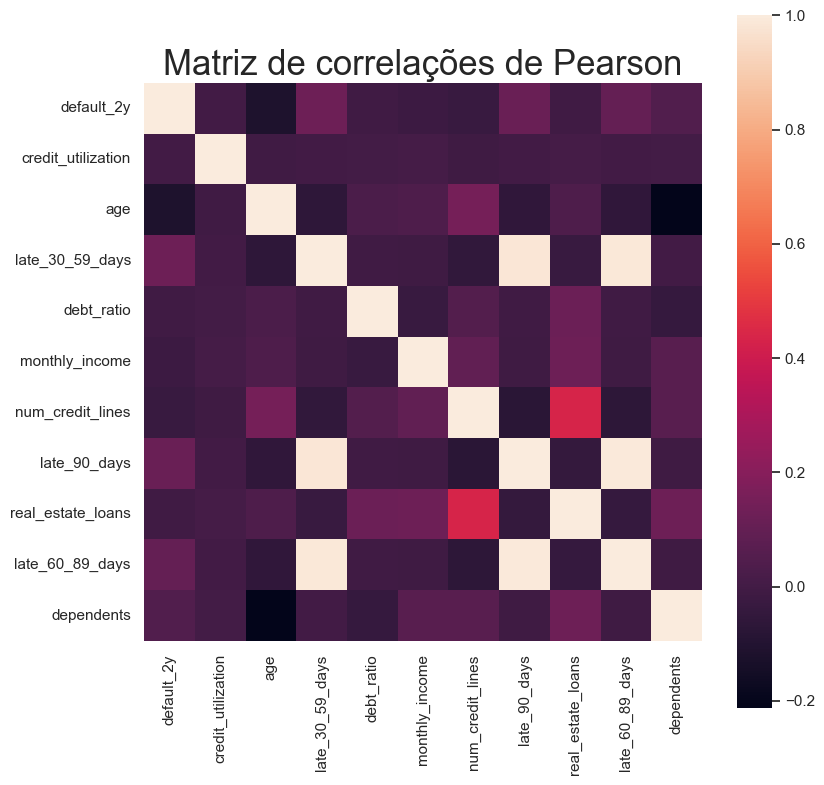

In [68]:
fig1, ax = plt.subplots(figsize=(9,9))
sns.heatmap(treino.corr(), square=True)

plt.title('Matriz de correlações de Pearson',fontsize=25)

Como podemos observar, as variáveis `late_30_59_days`, `late_60_89_days` e `late_90_days` tem correlação próxima de $1$. Na próxima seção, além de tratar dados faltantes, vamos fazer uma engenharia de features nas variáveis mencionadas anteriormente.

## 3. Tratamento dos dados

As decisoes desta etapa foram:

- substituir `age == 0` pela mediana das idades validas;
- criar flags de faltantes para `monthly_income` e `dependents`;
- Atribuir `monthly_income` e `dependents` usando a mediana por faixa etaria calculada **no treino**;
- Criar uma nova variável, `late_score` para representar contas atrasadas e agrupar as variáveis correlacionadas `late_30_59_days`, `late_60_89_days` e `late_90_days`;
- reaproveitar as medianas do treino ao tratar o conjunto de teste.

In [69]:
def tratar_dados(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    #Mediana da idade desconsiderando linhas com idade = 0 no conjunto de treino
    idade_mediana = train_df.loc[train_df['age'] > 0, 'age'].median()

    #Atribuir mediana das idades tanto no treino quanto no teste
    train_df.loc[train_df['age'] < 18, 'age'] = idade_mediana
    test_df.loc[test_df['age'] < 18, 'age'] = idade_mediana
    
    #Cria novas variáveis inteiras indicando que existem dados faltando nas colunas monthly_income e dependents - 1 caso falte e 0 caso contrário
    for col in ['monthly_income', 'dependents']:
        train_df[f'{col}_missing'] = train_df[col].isna().astype(int)
        test_df[f'{col}_missing'] = test_df[col].isna().astype(int)

    #Categoriza as pessoas entre jovem (18 a 29 anos), adulto (30 a 59 anos) e idoso (60+ anos)
    bins = [18, 30, 60, 120]
    labels = ['jovem', 'adulto', 'idoso']
    train_df['age_band'] = pd.cut(train_df['age'], bins=bins, labels=labels, include_lowest=True)
    test_df['age_band'] = pd.cut(test_df['age'], bins=bins, labels=labels, include_lowest=True)
    
    #Calcula medianas de cada bin - retorna uma serie de medianas de cada bin
    income_medians = train_df.groupby('age_band', observed=False)['monthly_income'].median()
    dep_medians = train_df.groupby('age_band', observed=False)['dependents'].median()

    #mapeia as linhas sem dados e preenche com as medianas
    train_df['monthly_income'] = train_df['monthly_income'].fillna(train_df['age_band'].map(income_medians))
    test_df['monthly_income'] = test_df['monthly_income'].fillna(test_df['age_band'].map(income_medians))
    
    train_df['dependents'] = train_df['dependents'].fillna(train_df['age_band'].map(dep_medians))
    test_df['dependents'] = test_df['dependents'].fillna(test_df['age_band'].map(dep_medians))

    #Cria uma nova variável para representar o atraso
    train_df['late_score'] = (
        1 * train_df['late_30_59_days'] +
        2 * train_df['late_60_89_days'] +
        3 * train_df['late_90_days']
    )
    test_df['late_score'] = (
        1 * test_df['late_30_59_days'] +
        2 * test_df['late_60_89_days'] +
        3 * test_df['late_90_days']
    )

    return train_df, test_df, income_medians, dep_medians

train_clean, test_clean, income_medians, dep_medians = tratar_dados(treino, teste)

print('Medianas de renda por faixa etaria:')
display(income_medians)
print('Medianas de dependentes por faixa etaria:')
display(dep_medians)

display(resumo_faltantes(train_clean))
display(resumo_faltantes(test_clean))
display(train_clean[['age', 'monthly_income', 'dependents', 'late_score']].describe())

Medianas de renda por faixa etaria:


age_band
jovem     2779.5
adulto    5833.0
idoso     5223.0
Name: monthly_income, dtype: float64

Medianas de dependentes por faixa etaria:


age_band
jovem     0.0
adulto    1.0
idoso     0.0
Name: dependents, dtype: float64

,faltantes,faltantes (%)


,faltantes,faltantes (%)
default_2y,101503,100.0


,age,monthly_income,dependents,late_score
count,150000.000000,1.500000e+05,150000.000000,150000.000000
mean,52.295553,6.419363e+03,0.747047,1.699727
std,14.771249,1.289421e+04,1.104911,24.928492
min,21.000000,0.000000e+00,0.000000,0.000000
25%,41.000000,3.778000e+03,0.000000,0.000000
50%,52.000000,5.436000e+03,0.000000,0.000000
75%,63.000000,7.400000e+03,1.000000,0.000000
max,109.000000,3.008750e+06,20.000000,588.000000


## 4. EDA

- Os dados sao desbalanceados ;
- Os boxplots indicam depêndencia do target com as variaveis `late_score` e `credit_utilization`.

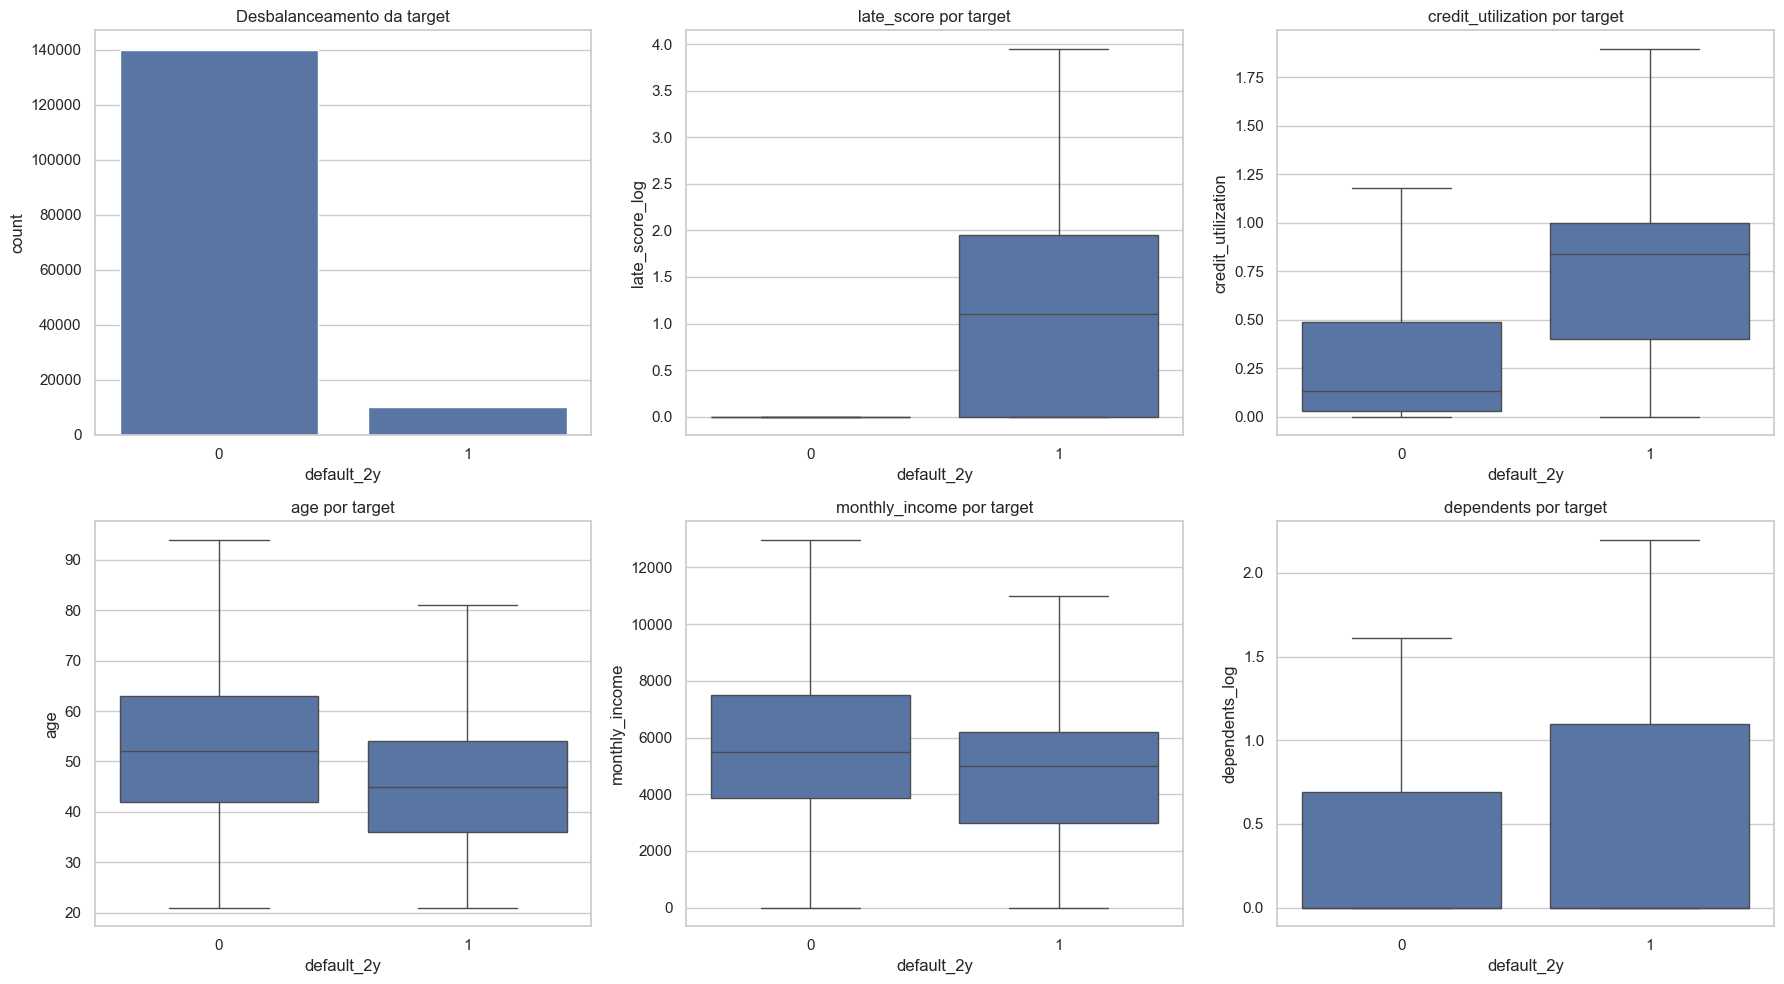

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=train_clean, x='default_2y', ax=axes[0][0])
axes[0][0].set_title('Desbalanceamento da target')

sns.boxplot(data=train_clean.assign(late_score_log=np.log1p(train_clean['late_score'])), x='default_2y', y='late_score_log', ax=axes[0][1], showfliers=False)
axes[0][1].set_title('late_score por target')

sns.boxplot(data=train_clean, x='default_2y', y='credit_utilization', ax=axes[0][2], showfliers=False)
axes[0][2].set_title('credit_utilization por target')

sns.boxplot(data=train_clean, x='default_2y', y='age', ax=axes[1][0], showfliers=False)
axes[1][0].set_title('age por target')

sns.boxplot(data=train_clean, x='default_2y', y='monthly_income', ax=axes[1][1], showfliers=False)
axes[1][1].set_title('monthly_income por target')

sns.boxplot(data=train_clean.assign(dependents_log=np.log1p(train_clean['dependents'])), x='default_2y', y='dependents_log', ax=axes[1][2], showfliers=False)
axes[1][2].set_title('dependents por target')

plt.tight_layout()
plt.show()

## 5. Regressão Logística - com função de ligação logito

Como estamos modelando a classificação de bons e maus pagadores, a variável target é uma Bernoulli. Por isso vou usar o modelo de regressão logística com a função de ligação canônica, a função logito.

Abaixo, crio uma função para treinar o modelo separando o conjunto de dados em treino e validação, mostrando as métricas de desempenho do modelo como acurácia e AUC.

## 5.1 Divisão em treino e validação

In [71]:
#train_clean.columns

#Retirei as colunas de atraso que foram agrupadas em late_score e as faixas de idade
features_base = [
    'credit_utilization',
    'age',
    'debt_ratio',
    'monthly_income',
    'num_credit_lines',
    'real_estate_loans',
    'dependents',
    'monthly_income_missing',
    'dependents_missing',
    'late_score'
]

target = 'default_2y'

X = train_clean[features_base].copy()
y = train_clean[target].copy()

X_t, X_v, y_t, y_v = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

## 5.2 Seleção de variáveis

1. AIC;
2. BIC;
3. L1 - Lasso.

In [86]:
late_score = ['late_score']

In [73]:
def stepwise_aic(X, y, verbose=True):
    X = X.copy()
    X = sm.add_constant(X)
    included = []
    best_aic = float('inf')#começa como infinito, qualquer modelo será melhor que o inicial

    while True:
        changed = False
        excluded = list(set(X.columns) - set(included) - {'const'})#colunas excluídas do modelo - inicialmente, temos todas colunas, exceto a const

        # Testa adições
        candidates = []
        for new_col in excluded:
            try:
                model = sm.GLM(y, X[['const'] + included + [new_col]], family=sm.families.Binomial()).fit()#cada passo inclui uma new_col
                candidates.append((model.aic, new_col, 'add'))
            except:
                continue

        # Testa remoções
        for remove_col in included:
            try:
                vars_test = [var for var in included if var != remove_col]
                model = sm.GLM(y, X[['const'] + vars_test], family=sm.families.Binomial()).fit()
                candidates.append((model.aic, remove_col, 'remove'))
            except:
                continue

        # Encontra o melhor movimento
        if candidates:
            candidates.sort()
            best_candidate_aic, best_candidate_var, action = candidates[0]
            if best_candidate_aic < best_aic:
                changed = True
                best_aic = best_candidate_aic
                if action == 'add':
                    included.append(best_candidate_var)
                    if verbose:
                        print(f' + {best_candidate_var:30} AIC={best_aic:.2f}')
                else:
                    included.remove(best_candidate_var)
                    if verbose:
                        print(f' - {best_candidate_var:30} AIC={best_aic:.2f}')

        if not changed:
            break

    if verbose:
        print('\nFinal model variables:')
        print(included)
    return included

features_AIC = stepwise_aic(X_t, y_t, verbose=True)

 + age                            AIC=57325.71
 + late_score                     AIC=56847.38
 + dependents                     AIC=56744.88
 + monthly_income                 AIC=56636.66
 + dependents_missing             AIC=56619.35
 + real_estate_loans              AIC=56604.03
 + debt_ratio                     AIC=56598.44
 + num_credit_lines               AIC=56594.79

Final model variables:
['age', 'late_score', 'dependents', 'monthly_income', 'dependents_missing', 'real_estate_loans', 'debt_ratio', 'num_credit_lines']


In [74]:
def stepwise_bic(X, y, verbose=True):
    X = sm.add_constant(X.copy(), has_constant='add')
    included = []

    null_model = sm.GLM(y, X[['const']], family=sm.families.Binomial()).fit()
    best_bic = null_model.bic_llf

    while True:
        changed = False
        excluded = [c for c in X.columns if c not in included and c != 'const']
        candidates = []

        for new_col in excluded:
            try:
                model = sm.GLM(
                    y, X[['const'] + included + [new_col]],
                    family=sm.families.Binomial()
                ).fit()
                candidates.append((model.bic_llf, new_col, 'add'))
            except Exception:
                pass

        for remove_col in included:
            try:
                vars_test = [v for v in included if v != remove_col]
                model = sm.GLM(
                    y, X[['const'] + vars_test],
                    family=sm.families.Binomial()
                ).fit()
                candidates.append((model.bic_llf, remove_col, 'remove'))
            except Exception:
                pass

        if not candidates:
            break

        candidates.sort(key=lambda x: x[0])
        cand_bic, cand_var, action = candidates[0]

        if cand_bic < best_bic:
            best_bic = cand_bic
            changed = True
            if action == 'add':
                included.append(cand_var)
                if verbose:
                    print(f'+ {cand_var:30} BIC={best_bic:.2f}')
            else:
                included.remove(cand_var)
                if verbose:
                    print(f'- {cand_var:30} BIC={best_bic:.2f}')

        if not changed:
            break

    if verbose:
        print('\nFinal model variables:')
        print(included)

    return included

features_BIC = stepwise_bic(X_t, y_t, verbose=True)

+ age                            BIC=57345.10
+ late_score                     BIC=56876.46
+ dependents                     BIC=56783.66
+ monthly_income                 BIC=56685.14
+ dependents_missing             BIC=56677.52
+ real_estate_loans              BIC=56671.90

Final model variables:
['age', 'late_score', 'dependents', 'monthly_income', 'dependents_missing', 'real_estate_loans']


In [136]:
def selecionar_variaveis_l1(X, y, feature_names, verbose=True):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            class_weight='balanced',
            penalty='l1',
            solver='saga',
            max_iter=2000,
            C=0.0005
        ))
    ])

    #Ajuste
    pipe.fit(X, y)

    coef = pd.Series(pipe.named_steps['model'].coef_[0], index=feature_names)
    selecionadas = coef[coef.abs() > 1e-8].index.tolist()

    if verbose:
        print('\nFinal model variables:')
        print(selecionadas)

    return selecionadas

features_L1 = selecionar_variaveis_l1(X_t, y_t, features_base)



Final model variables:
['age', 'dependents', 'late_score']


## 5.3 Avaliação do Modelo

In [120]:
def encontrar_limiar_otimo(y_true, probas):
    melhor_resultado = None

    for th in np.linspace(0.01, 1, 1001):
        y_pred = (probas >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        acc = accuracy_score(y_true, y_pred)

        if tpr >= 0.65:
            if (
                melhor_resultado is None
                or acc > melhor_resultado['acuracia']
                or (tpr > melhor_resultado['tpr'] and acc == melhor_resultado['acuracia'])
            ):
                melhor_resultado = {
                    'limiar': th,
                    'acuracia': acc,
                    'tpr': tpr,
                    'fpr': fpr,
                }

    if melhor_resultado is None:
        return 0.5

    return melhor_resultado['limiar']


def avaliar_probabilidades(y_true, probas, limiar):
    y_pred = (probas >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensibilidade = recall_score(y_true, y_pred, pos_label=1)
    especificidade = recall_score(y_true, y_pred, pos_label=0)

    return {
        'limiar': round(float(limiar), 3),
        'acuracia': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, probas),
        'sensibilidade': sensibilidade,
        'especificidade': especificidade,
        'ks': sensibilidade - (fp / (fp + tn)),
    }

In [77]:
def avaliar_logito(X_t, y_t, X_v, y_v, features, nome_selecao, summary=True):
    X_t = sm.add_constant(X_t[features], has_constant='add')
    X_v = sm.add_constant(X_v[features], has_constant='add')

    modelo = sm.GLM(y_t, X_t, family=sm.families.Binomial()).fit()

    p_t = modelo.predict(X_t)
    p_v = modelo.predict(X_v)

    limiar_otimo = encontrar_limiar_otimo(y_t, p_t)

    linhas = []
    for regra, limiar in [('fixo_0.5', 0.5), ('otimo', limiar_otimo)]:
        metricas_t = avaliar_probabilidades(y_t, p_t, limiar)
        metricas_v = avaliar_probabilidades(y_v, p_v, limiar)

        linhas.append({
            'Seleção': nome_selecao,
            'n_variaveis': len(features),
            'regra_limiar': regra,
            'limiar': limiar,
            'acuracia_treino': metricas_t['acuracia'],
            'auc_treino': metricas_t['auc'],
            'sensibilidade_treino': metricas_t['sensibilidade'],
            'especificidade_treino': metricas_t['especificidade'],
            #'ks_treino': metricas_t['ks'],
            'acuracia_validacao': metricas_v['acuracia'],
            'auc_validacao': metricas_v['auc'],
            'sensibilidade_validacao': metricas_v['sensibilidade'],
            'especificidade_validacao': metricas_v['especificidade'],
            #'ks_validacao': metricas_v['ks'],
        })

    if summary:
        print(modelo.summary())

    return linhas, modelo, p_t, p_v


In [137]:
resultados = []
#modelos_roc = {}
predicoes_roc_t = {}
predicoes_roc_v = {}

for nome, features in {
    'Base': features_base,
    'Late_Score': late_score,
    'Stepwise AIC': features_AIC,
    'Stepwise BIC': features_BIC,
    'L1 - Lasso': features_L1
}.items():
    linhas, model, p_t, p_v = avaliar_logito(X_t, y_t, X_v, y_v, features, nome, summary=False)
    resultados.extend(linhas)
    #modelos_roc[nome] = model
    predicoes_roc_t[nome] = p_t
    predicoes_roc_v[nome] = p_v


comparacao = pd.DataFrame(resultados)
comparacao[
    ['acuracia_treino', 
     'auc_treino', 
     'sensibilidade_treino', 
     'especificidade_treino',
     'acuracia_validacao', 
     'auc_validacao', 
     'sensibilidade_validacao', 
     'especificidade_validacao']] = comparacao[
        ['acuracia_treino', 
         'auc_treino', 
         'sensibilidade_treino', 
         'especificidade_treino',
         'acuracia_validacao', 
         'auc_validacao', 
         'sensibilidade_validacao', 
         'especificidade_validacao']].round(3)
comparacao.sort_values(['auc_validacao', 'sensibilidade_validacao', 'acuracia_validacao', 'especificidade_validacao'], ascending=False)

,Seleção,n_variaveis,regra_limiar,limiar,acuracia_treino,auc_treino,sensibilidade_treino,especificidade_treino,acuracia_validacao,auc_validacao,sensibilidade_validacao,especificidade_validacao
3,Late_Score,1,otimo,0.06544,0.821,0.779,0.673,0.831,0.822,0.783,0.680,0.832
2,Late_Score,1,fixo_0.5,0.50000,0.933,0.779,0.015,0.999,0.933,0.783,0.015,0.999
7,Stepwise BIC,6,otimo,0.06445,0.566,0.655,0.656,0.559,0.568,0.671,0.680,0.560
6,Stepwise BIC,6,fixo_0.5,0.50000,0.933,0.655,0.014,0.999,0.933,0.671,0.015,0.999
1,Base,10,otimo,0.06445,0.569,0.656,0.658,0.563,0.571,0.669,0.680,0.563
5,Stepwise AIC,8,otimo,0.06445,0.569,0.656,0.657,0.563,0.571,0.669,0.679,0.563
0,Base,10,fixo_0.5,0.50000,0.933,0.656,0.014,0.999,0.933,0.669,0.015,0.999
4,Stepwise AIC,8,fixo_0.5,0.50000,0.933,0.656,0.014,0.999,0.933,0.669,0.015,0.999
9,L1 - Lasso,3,otimo,0.06445,0.552,0.647,0.659,0.544,0.556,0.664,0.688,0.547
8,L1 - Lasso,3,fixo_0.5,0.50000,0.933,0.647,0.014,0.999,0.933,0.664,0.015,0.999


In [148]:
cols = [
    'Seleção', 'n_variaveis', 'limiar',
    'acuracia_validacao', 'auc_validacao',
    'sensibilidade_validacao', 'especificidade_validacao'
]

latex_tab = comparacao[cols].to_latex(
    index=False,
    caption='Comparação dos modelos na validação',
    label='tab:comparacao_modelos_validacao',
    float_format='%.3f'
)

print(latex_tab)

\begin{table}
\caption{Comparação dos modelos na validação}
\label{tab:comparacao_modelos_validacao}
\begin{tabular}{lrrrrrr}
\toprule
Seleção & n_variaveis & limiar & acuracia_validacao & auc_validacao & sensibilidade_validacao & especificidade_validacao \\
\midrule
Base & 10 & 0.500 & 0.933 & 0.669 & 0.015 & 0.999 \\
Base & 10 & 0.064 & 0.571 & 0.669 & 0.680 & 0.563 \\
Late_Score & 1 & 0.500 & 0.933 & 0.783 & 0.015 & 0.999 \\
Late_Score & 1 & 0.065 & 0.822 & 0.783 & 0.680 & 0.832 \\
Stepwise AIC & 8 & 0.500 & 0.933 & 0.669 & 0.015 & 0.999 \\
Stepwise AIC & 8 & 0.064 & 0.571 & 0.669 & 0.679 & 0.563 \\
Stepwise BIC & 6 & 0.500 & 0.933 & 0.671 & 0.015 & 0.999 \\
Stepwise BIC & 6 & 0.064 & 0.568 & 0.671 & 0.680 & 0.560 \\
L1 - Lasso & 3 & 0.500 & 0.933 & 0.664 & 0.015 & 0.999 \\
L1 - Lasso & 3 & 0.064 & 0.556 & 0.664 & 0.688 & 0.547 \\
\bottomrule
\end{tabular}
\end{table}



## 5.4 Curvas ROC-AUC por estrategia de selecao de variaveis


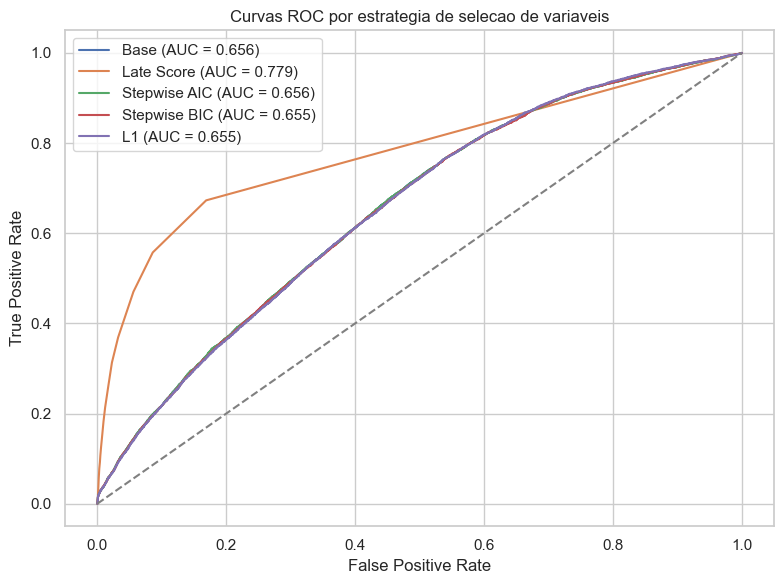

In [126]:
fpr_base_t, tpr_base_t, _ = roc_curve(y_t, predicoes_roc_t['Base'])
fpr_late_t, tpr_late_t, _ = roc_curve(y_t, predicoes_roc_t['Late_Score'])
fpr_aic_t, tpr_aic_t, _ = roc_curve(y_t, predicoes_roc_t['Stepwise AIC'])
fpr_bic_t, tpr_bic_t, _ = roc_curve(y_t, predicoes_roc_t['Stepwise BIC'])
fpr_l1_t, tpr_l1_t, _ = roc_curve(y_t, predicoes_roc_t['L1 - Lasso'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_base_t, tpr_base_t, label=f"Base (AUC = {roc_auc_score(y_t, predicoes_roc_t['Base']):.3f})")
plt.plot(fpr_late_t, tpr_late_t, label=f"Late Score (AUC = {roc_auc_score(y_t, predicoes_roc_t['Late_Score']):.3f})")
plt.plot(fpr_aic_t, tpr_aic_t, label=f"Stepwise AIC (AUC = {roc_auc_score(y_t, predicoes_roc_t['Stepwise AIC']):.3f})")
plt.plot(fpr_bic_t, tpr_bic_t, label=f"Stepwise BIC (AUC = {roc_auc_score(y_t, predicoes_roc_t['Stepwise BIC']):.3f})")
plt.plot(fpr_l1_t, tpr_l1_t, label=f"L1 (AUC = {roc_auc_score(y_t, predicoes_roc_t['L1 - Lasso']):.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC por estrategia de selecao de variaveis')
plt.legend()
plt.tight_layout()
plt.savefig('curvas_roc_selecao_variaveis_com_bic.pdf', format='pdf', bbox_inches='tight')
plt.show()

## 5.5 Matriz de confusão para o modelo somente com `late_score`

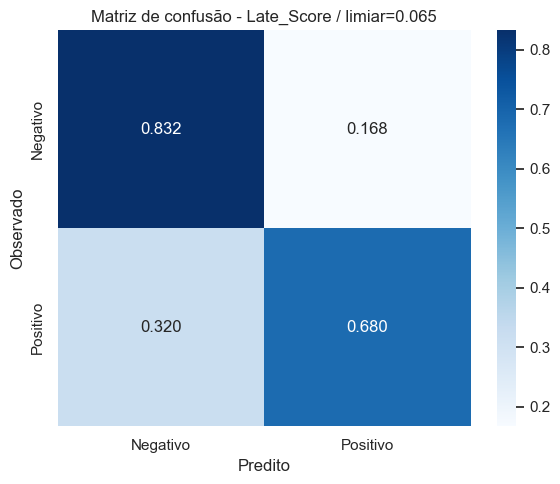

,Predito 0,Predito 1
Observado 0,0.832434,0.167566
Observado 1,0.319701,0.680299


,Seleção,n_variaveis,regra_limiar,limiar,acuracia_treino,auc_treino,sensibilidade_treino,especificidade_treino,acuracia_validacao,auc_validacao,sensibilidade_validacao,especificidade_validacao
3,Late_Score,1,otimo,0.06544,0.821,0.779,0.673,0.831,0.822,0.783,0.68,0.832


In [146]:
melhor_modelo = comparacao[
    (comparacao['Seleção'] == 'Late_Score') &
    (comparacao['regra_limiar'] == 'otimo')
].iloc[0].copy()

probas_melhor = predicoes_roc_v['Late_Score']
y_pred_melhor = (probas_melhor >= melhor_modelo['limiar']).astype(int)
cm_taxas = confusion_matrix(y_v, y_pred_melhor, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_taxas,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo']
)
plt.title(
    f"Matriz de confusão - "
    f"{melhor_modelo['Seleção']} / limiar={melhor_modelo['limiar']:.3f}"
)
plt.xlabel('Predito')
plt.ylabel('Observado')
plt.tight_layout()
plt.savefig('matriz_confusao.pdf', format='pdf', bbox_inches='tight')
plt.show()

taxas_confusao = pd.DataFrame(
    cm_taxas,
    index=['Observado 0', 'Observado 1'],
    columns=['Predito 0', 'Predito 1']
)

display(taxas_confusao)
melhor_modelo.to_frame().T



## 6. Regressão logística com k-fold

In [142]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    X_treino, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_treino, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    print(f'Fold {fold}')
    print(X_treino.shape, X_val.shape)


Fold 1
(120000, 10) (30000, 10)
Fold 2
(120000, 10) (30000, 10)
Fold 3
(120000, 10) (30000, 10)
Fold 4
(120000, 10) (30000, 10)
Fold 5
(120000, 10) (30000, 10)


In [143]:
X_treino.head()

,credit_utilization,age,debt_ratio,monthly_income,num_credit_lines,real_estate_loans,dependents,monthly_income_missing,dependents_missing,late_score
0,0.766127,45,0.802982,9120.0,13,6,2.0,0,0,2
1,0.957151,40,0.121876,2600.0,4,0,1.0,0,0,0
3,0.233810,30,0.036050,3300.0,5,0,0.0,0,0,0
4,0.907239,49,0.024926,63588.0,7,1,0.0,0,0,1
5,0.213179,74,0.375607,3500.0,3,1,1.0,0,0,0
